#  Group Term paper 1 
**Candidate number 67 and {insert}**
***

In [25]:
import sys
print(sys.executable)

/opt/anaconda3/envs/FIE463/bin/python


In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

In [2]:
class Parameters:
    def __init__(self):
        self.beta = 0.99**30
        self.epsilon = 2.1
        self.tau = 0.3
        self.rho = 0.5
        self.alpha = 0.36
        self.delta = 1 - 0.94**30
        self.z = 1.0
        self.Nw = 0.8
        self.Nk = 0.2
        self.tau_a = 0.0
        self.tau_a_iid = 0.05
        self.pi_a = 0.5

par = Parameters()

## Part 1 - Euler equation errors
***

In [3]:
def euler_err(K_next, K, par):
    """
    Compute the capitalists' Euler equation error for a given capital
    stock today and tomorrow.
    """
    # Labor supply
    L = 0.5 * par.Nw

    # Interest rates from firm FOC
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Transfers from wealth tax
    Ta = par.tau_a * (1 + r) * K
    Ta_next = par.tau_a * (1 + r_next) * K_next

    # Household variables from market clearing
    a = 2 * K_next / par.Nk
    b = par.rho * (1 - par.tau_a) * (1 + r) * (2 * K / par.Nk)

    # Euler equation error: LHS - RHS
    LHS = (b + Ta - a)**(-par.epsilon)
    RHS = par.beta * (1 + r_next) * (1 - par.tau_a) * (1 - par.rho) * ((1 - par.rho) * (1 - par.tau_a) * (1 + r_next) * a + Ta_next)**(-par.epsilon)

    return LHS - RHS

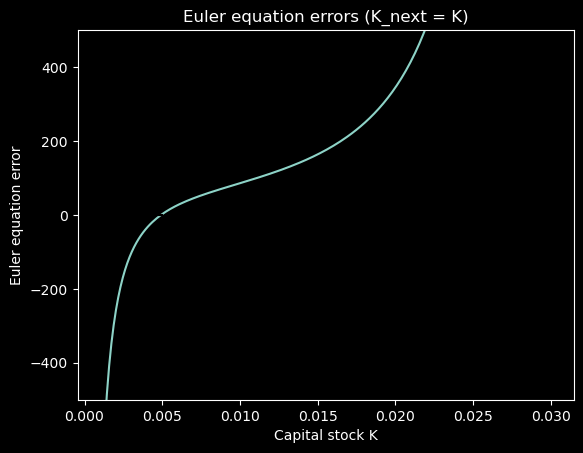

In [4]:
K_grid = np.linspace(0.001, 0.03, 200)
errors = [euler_err(K, K, par) for K in K_grid]

plt.figure()
plt.plot(K_grid, errors)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Capital stock K')
plt.ylabel('Euler equation error')
plt.title('Euler equation errors (K_next = K)')
plt.ylim(-500, 500)
plt.show()

The plot shows that the Euler equation error crosses zero around K = 0.005, confirming that the function has a root. 

## Part 2 - Steady state
***

In [5]:
class SteadyState:
    """Stores all steady-state quantities and prices."""
    pass


In [6]:
def compute_steady_state(par, euler_func=euler_err):
    """Compute the steady state of the OLG model."""

    K_ss = optimize.brentq(lambda K: euler_func(K, K, par), 0.001, 0.02)

    ss = SteadyState()
    ss.K = K_ss

    # Prices
    L = 0.5 * par.Nw
    ss.L = L
    ss.r = par.alpha * par.z * ss.K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    ss.w = (1 - par.alpha) * par.z * ss.K**par.alpha * L**(-par.alpha)
    ss.Y = par.z * ss.K**par.alpha * L**(1 - par.alpha)

    # Transfers from wealth tax
    ss.Ta = par.tau_a * (1 + ss.r) * ss.K

    # Capitalist variables
    ss.a = 2 * ss.K / par.Nk
    ss.b = par.rho * (1 - par.tau_a) * (1 + ss.r) * ss.a
    ss.ck_y = ss.b + ss.Ta - ss.a
    ss.ck_o = (1 - par.rho) * (1 - par.tau_a) * (1 + ss.r) * ss.a + ss.Ta
    ss.s = ss.a / (ss.b + ss.Ta)

    # Worker variables
    ss.p = par.tau * ss.w
    ss.cw_y = (1 - par.tau) * ss.w + ss.Ta
    ss.cw_o = ss.p + ss.Ta

    return ss

In [7]:
ss = compute_steady_state(par)

print("Steady-state equilibrium:")
print(f"  Output Y     = {ss.Y:.6f}")
print(f"  Capital K    = {ss.K:.6f}")
print(f"  Wage w       = {ss.w:.6f}")
print(f"  Interest r   = {ss.r:.6f}")
print(f"  Bequest b    = {ss.b:.6f}")
print(f"  Savings a    = {ss.a:.6f}")
print(f"  cw_y         = {ss.cw_y:.6f}")
print(f"  cw_o         = {ss.cw_o:.6f}")
print(f"  ck_y         = {ss.ck_y:.6f}")
print(f"  ck_o         = {ss.ck_o:.6f}")

Steady-state equilibrium:
  Output Y     = 0.082129
  Capital K    = 0.004922
  Wage w       = 0.131407
  Interest r   = 5.162944
  Bequest b    = 0.151678
  Savings a    = 0.049223
  cw_y         = 0.091985
  cw_o         = 0.039422
  ck_y         = 0.102456
  ck_o         = 0.151678


In [8]:
# Verify goods market clearing
LHS = ss.Y + (1 - par.delta) * ss.K
RHS = 0.5 * par.Nw * (ss.cw_y + ss.cw_o) + 0.5 * par.Nk * (ss.ck_y + ss.ck_o + ss.a)
print(f"Goods market clearing check: LHS - RHS = {LHS - RHS:.2e}")

# Annualized net interest rates
r_annual = (1 + ss.r)**(1/30) - 1
print(f"Annualized net interest rate: {r_annual*100:.2f}%")

Goods market clearing check: LHS - RHS = 0.00e+00
Annualized net interest rate: 6.25%


The annualized net interest rate of 6.25% is a reasonable value, which suggests the model is calibrated correctly. 

## Part 3 - Transition dynamics
***

In [9]:
class Simulation:
    """Stores simulated time series of all model variables."""
    pass

In [10]:
def simulate_olg(K0, T, par, euler_func=euler_err):
    """Simulate the OLG model for T periods starting from K0."""

    sim = Simulation()

    sim.K = np.zeros(T)
    sim.Y = np.zeros(T)
    sim.r = np.zeros(T)
    sim.w = np.zeros(T)
    sim.a = np.zeros(T)
    sim.b = np.zeros(T)
    sim.s = np.zeros(T)
    sim.Ta = np.zeros(T)
    sim.cw_y = np.zeros(T)
    sim.cw_o = np.zeros(T)
    sim.ck_y = np.zeros(T)
    sim.ck_o = np.zeros(T)

    L = 0.5 * par.Nw
    sim.K[0] = K0

    for t in range(T):
        K = sim.K[t]

        # Prices
        sim.r[t] = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
        sim.w[t] = (1 - par.alpha) * par.z * K**par.alpha * L**(-par.alpha)
        sim.Y[t] = par.z * K**par.alpha * L**(1 - par.alpha)
        

        # Transfers from wealth tax
        sim.Ta[t] = par.tau_a * (1 + sim.r[t]) * K

        # Capitalist variables
        sim.b[t] = par.rho * (1 - par.tau_a) * (1 + sim.r[t]) * (2 * K / par.Nk)

        # Find next period capital using root-finder
        if t < T - 1:
            K_upper = (sim.b[t] + sim.Ta[t]) * par.Nk / 2 * 0.99
            K_next = optimize.brentq(lambda Kn: euler_func(Kn, K, par), 0.0001, K_upper)
            sim.K[t + 1] = K_next

        sim.a[t] = 2 * sim.K[min(t + 1, T - 1)] / par.Nk
        sim.ck_y[t] = sim.b[t] + sim.Ta[t] - sim.a[t]
        sim.ck_o[t] = (1 - par.rho) * (1 - par.tau_a) * (1 + sim.r[t]) * (2 * K / par.Nk) + sim.Ta[t]
        sim.s[t] = sim.a[t] / (sim.b[t] + sim.Ta[t])

        # Worker consumption
        sim.cw_y[t] = (1 - par.tau) * sim.w[t] + sim.Ta[t]
        sim.cw_o[t] = par.tau * sim.w[t] + sim.Ta[t]

    return sim

In [11]:
sim = simulate_olg(ss.K / 2, 20, par)

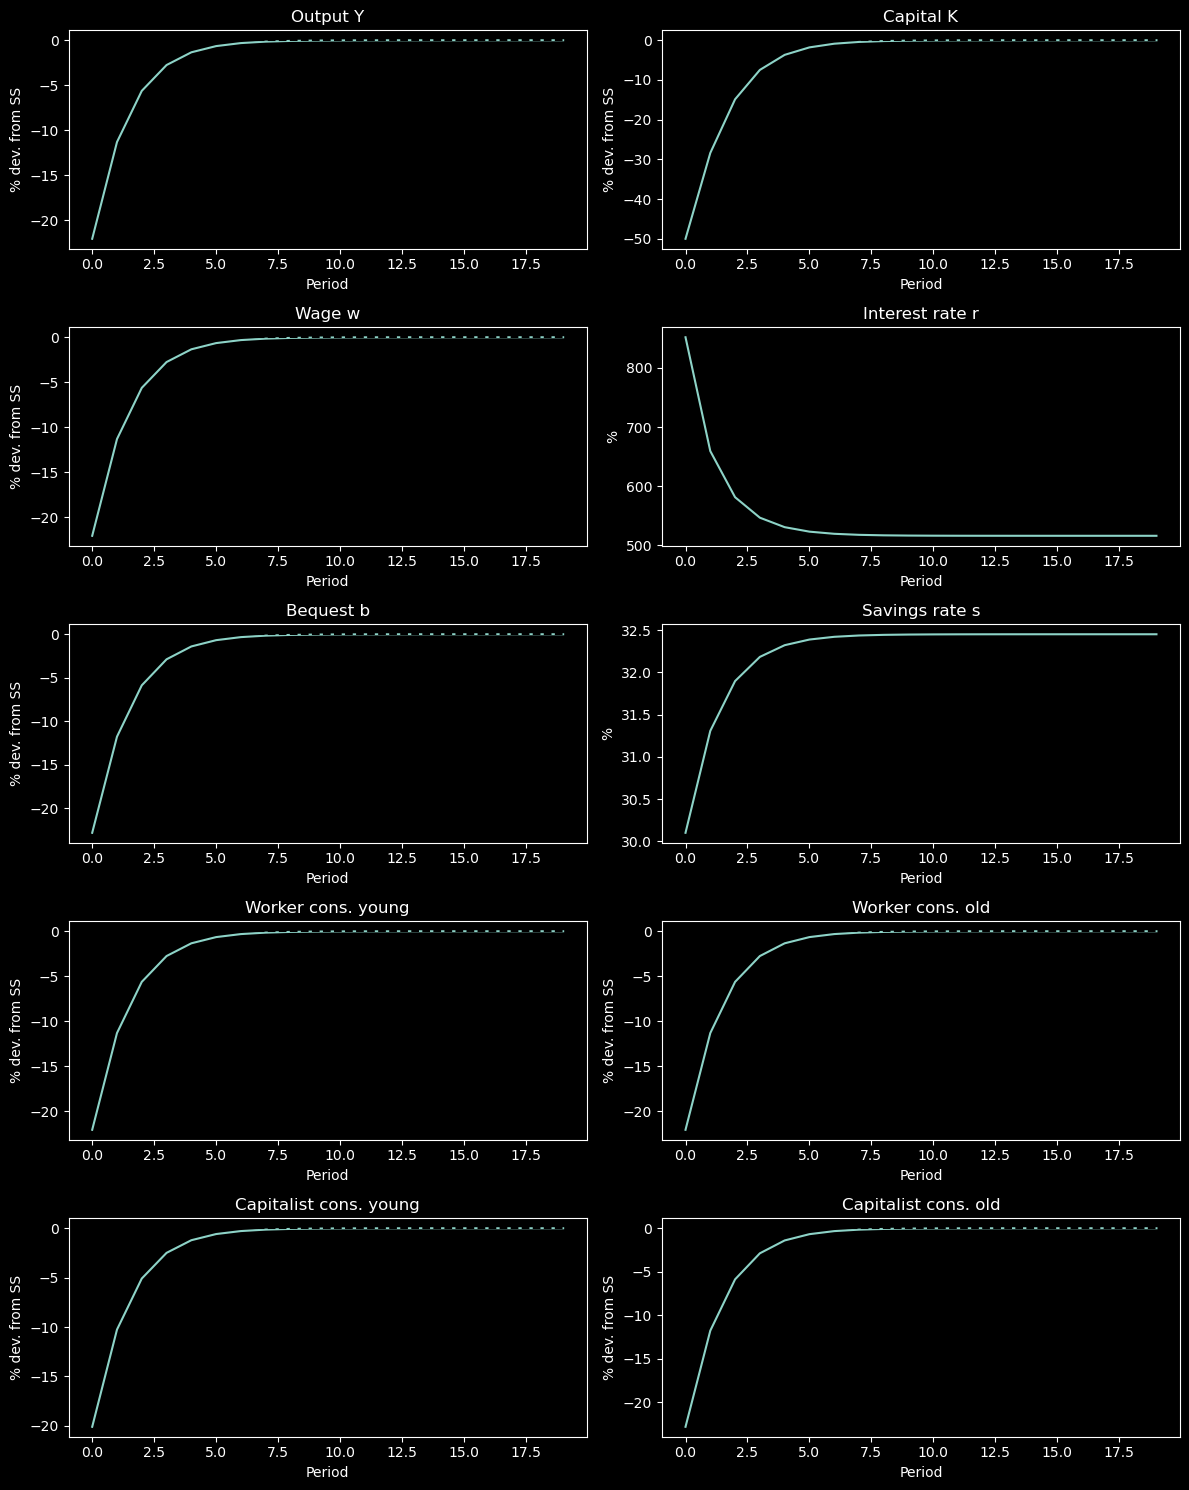

In [12]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

# Variables as percent deviation from steady state
pct_vars = [
    (sim.Y, ss.Y, 'Output Y'),
    (sim.K, ss.K, 'Capital K'),
    (sim.w, ss.w, 'Wage w'),
    (sim.r, None, 'Interest rate r'),
    (sim.b, ss.b, 'Bequest b'),
    (sim.s, None, 'Savings rate s'),
    (sim.cw_y, ss.cw_y, 'Worker cons. young'),
    (sim.cw_o, ss.cw_o, 'Worker cons. old'),
    (sim.ck_y, ss.ck_y, 'Capitalist cons. young'),
    (sim.ck_o, ss.ck_o, 'Capitalist cons. old'),
]

for i, (series, ss_val, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if ss_val is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - ss_val) / ss_val)
        ax.axhline(0, color='black', linestyle='--')
        ax.set_ylabel('% dev. from SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

The economy converges to the steady state, confirming that the steady state computed in part 2 is correct. 

## Part 4 - Introduction of a wealth tax
***

In [13]:
# Save old steady state
ss_old = ss

# Set wealth tax rate
par.tau_a = 0.05

# New steady state
ss_new = compute_steady_state(par)

print("New steady state with wealth tax:")
print(f"  Output Y     = {ss_new.Y:.6f}")
print(f"  Capital K    = {ss_new.K:.6f}")
print(f"  Wage w       = {ss_new.w:.6f}")
print(f"  Interest r   = {ss_new.r:.6f}")
print(f"  Savings rate = {ss_new.s*100:.2f}%")
print(f"  Transfer Ta  = {ss_new.Ta:.6f}")
print(f"  cw_y         = {ss_new.cw_y:.6f}")
print(f"  cw_o         = {ss_new.cw_o:.6f}")
print(f"  ck_y         = {ss_new.ck_y:.6f}")
print(f"  ck_o         = {ss_new.ck_o:.6f}")

print(f"\nChange in capital: {100*(ss_new.K - ss_old.K)/ss_old.K:.2f}%")
print(f"Change in savings rate: {100*(ss_new.s - ss_old.s):.2f} pp")

New steady state with wealth tax:
  Output Y     = 0.079977
  Capital K    = 0.004572
  Wage w       = 0.127963
  Interest r   = 5.453349
  Savings rate = 32.28%
  Transfer Ta  = 0.001475
  cw_y         = 0.091049
  cw_o         = 0.039864
  ck_y         = 0.095907
  ck_o         = 0.141629

Change in capital: -7.11%
Change in savings rate: -0.17 pp


The wealth tax reduces the capital stock by 7.11% and the savings rate by 0.17 percentage points. This is because the tax lowers the return on savings for capitalists, so they save less. 

In [14]:
sim4 = simulate_olg(ss_old.K, 20, par)

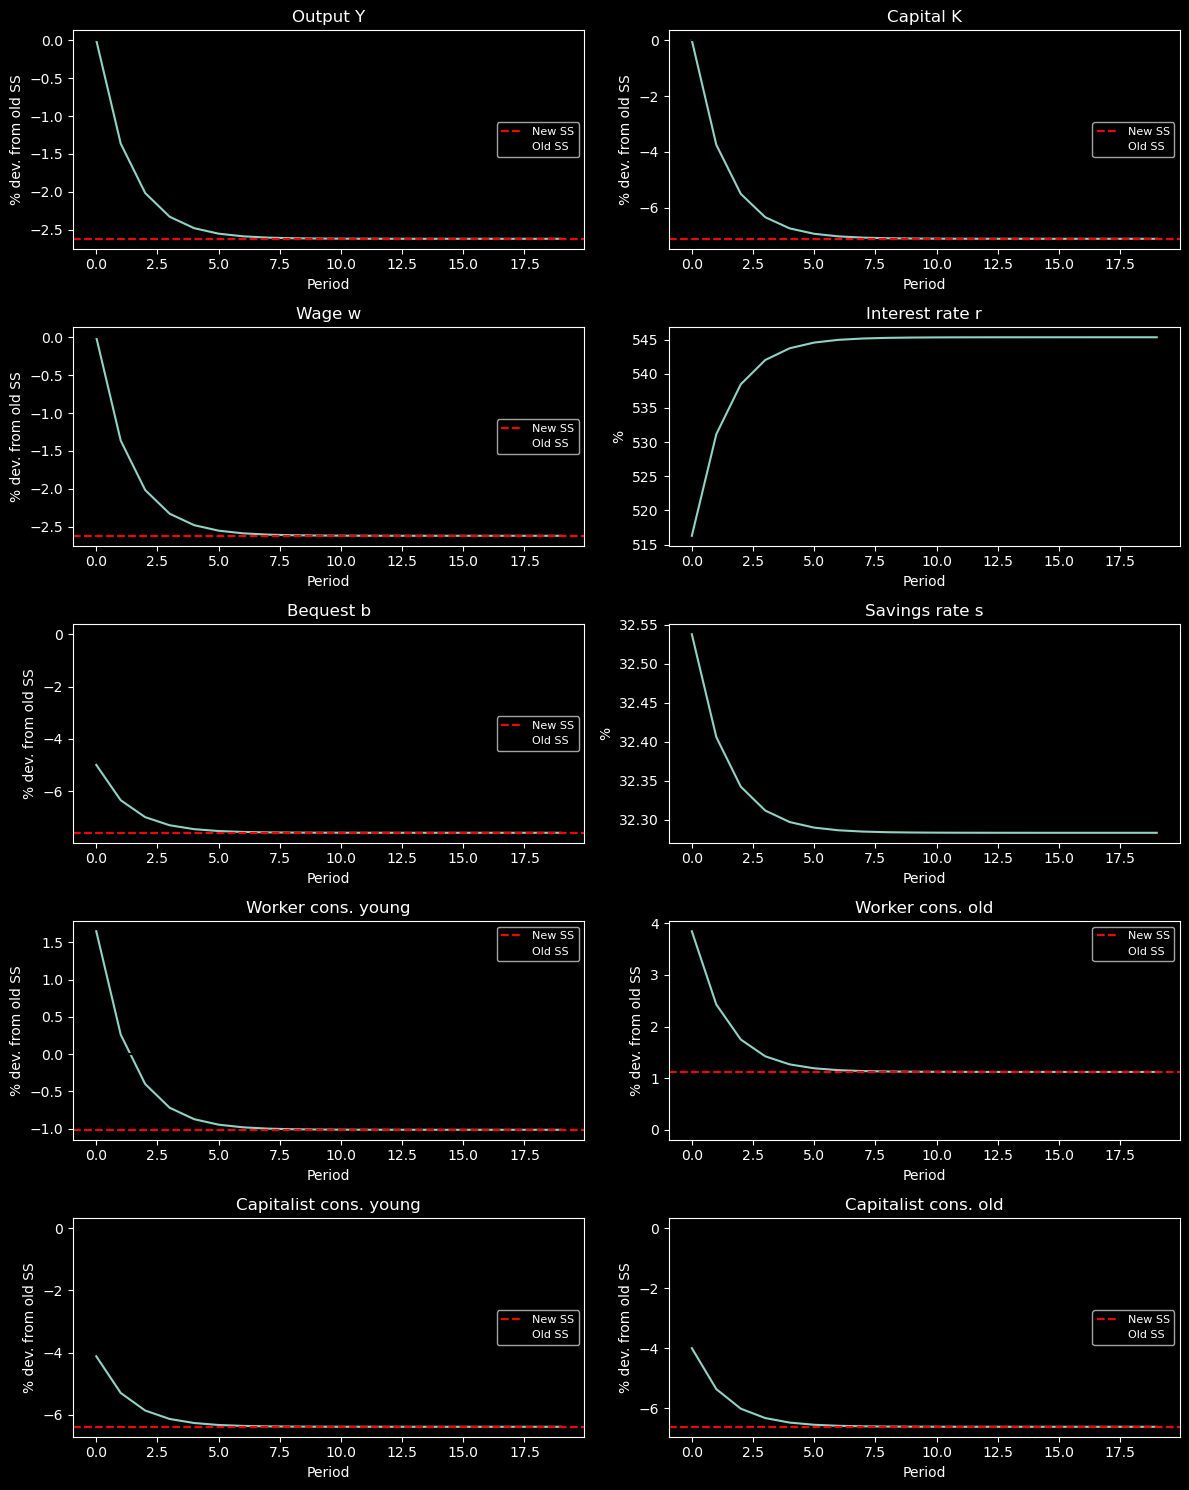

In [15]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

pct_vars = [
    (sim4.Y, ss_old.Y, ss_new.Y, 'Output Y'),
    (sim4.K, ss_old.K, ss_new.K, 'Capital K'),
    (sim4.w, ss_old.w, ss_new.w, 'Wage w'),
    (sim4.r, None, None, 'Interest rate r'),
    (sim4.b, ss_old.b, ss_new.b, 'Bequest b'),
    (sim4.s, None, None, 'Savings rate s'),
    (sim4.cw_y, ss_old.cw_y, ss_new.cw_y, 'Worker cons. young'),
    (sim4.cw_o, ss_old.cw_o, ss_new.cw_o, 'Worker cons. old'),
    (sim4.ck_y, ss_old.ck_y, ss_new.ck_y, 'Capitalist cons. young'),
    (sim4.ck_o, ss_old.ck_o, ss_new.ck_o, 'Capitalist cons. old'),
]

for i, (series, old, new, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if old is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - old) / old)
        ax.axhline(100 * (new - old) / old, color='red', linestyle='--', label='New SS')
        ax.axhline(0, color='black', linestyle='--', label='Old SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('% dev. from old SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()

Workers are initially better off due to the transfer from the wealht tax, but worse off in the new steady state as lower capital reduces wages. Old workers benefit since the transfer more than offsets the wage decline. Capitalists are worse of both along the transition and in the new steady state as the tax directly reduces their wealth and consumption. 

## Part 5 - Social welfare and the optimal wealth tax
***

In [16]:
def crra_utility(c, epsilon):
    """CRRA utility function."""
    if epsilon == 1:
        return np.log(c)
    else:
        return c**(1 - epsilon) / (1 - epsilon)

In [17]:
def social_welfare(ss, par):
    """Compute utilitarian social welfare in steady state."""

    # Young worker: u(cw_y) + beta * u(cw_o)
    Uw_y = crra_utility(ss.cw_y, par.epsilon) + par.beta * crra_utility(ss.cw_o, par.epsilon)
    # Old worker: u(cw_o)
    Uw_o = crra_utility(ss.cw_o, par.epsilon)
    # Young capitalist: u(ck_y) + beta * u(ck_o)
    
    Uk_y = crra_utility(ss.ck_y, par.epsilon) + par.beta * crra_utility(ss.ck_o, par.epsilon)
    # Old capitalist: u(ck_o)
    Uk_o = crra_utility(ss.ck_o, par.epsilon)

    SW = 0.5 * par.Nw * (Uw_y + Uw_o) + 0.5 * par.Nk * (Uk_y + Uk_o)
    return SW

In [18]:
# Welfare without wealth tax
par.tau_a = 0.0
ss_no_tax = compute_steady_state(par)
SW_no_tax = social_welfare(ss_no_tax, par)

# Welfare with wealth tax
par.tau_a = 0.05
ss_with_tax = compute_steady_state(par)
SW_with_tax = social_welfare(ss_with_tax, par)

print(f"Social welfare without wealth tax: {SW_no_tax:.6f}")
print(f"Social welfare with wealth tax:    {SW_with_tax:.6f}")

if SW_with_tax > SW_no_tax:
    print("Households prefer the steady state with the wealth tax.")
else:
    print("Households prefer the steady state without the wealth tax.")

Social welfare without wealth tax: -29.565242
Social welfare with wealth tax:    -29.534233
Households prefer the steady state with the wealth tax.


OLd workers benefit from the wealth tax transfer, while young workers are slightly worse off due to lower wages. Capitalists are worse off. Since workers make up to 80% of the population and the utility gains from redistribution outweight the lossess, welfare is higher with the wealth tax. 

In [19]:
def neg_welfare(tau_a):
    """Negative social welfare function of tau_a (for minimization)."""
    par.tau_a = tau_a
    try:
        ss_temp = compute_steady_state(par)
        return -social_welfare(ss_temp, par)
    except:
        return 0.0

result = optimize.minimize_scalar(neg_welfare, bounds=(0.001, 0.3), method='bounded')
tau_a_opt = result.x

print(f"Optimal wealth tax rate: {tau_a_opt*100:.2f}%")

Optimal wealth tax rate: 4.06%


In [20]:
par.tau_a = tau_a_opt
ss_opt = compute_steady_state(par)

print(f"Change in output Y: {100*(ss_opt.Y - ss_no_tax.Y)/ss_no_tax.Y:.2f}%")
print(f"Change in capital K: {100*(ss_opt.K - ss_no_tax.K)/ss_no_tax.K:.2f}%")

Change in output Y: -2.12%
Change in capital K: -5.78%


Even though output and capital are lower, welfare is higher because the wealth tax redistributes resources from capitalists to workers. Since workers have lower consumption, the utility gain for workers outweights the utility loss for capitalists.

## Part 6 - Uncertainty about wealth taxes
***

In [21]:
def euler_err_uncertain(K_next, K, par):
    """
    Euler equation error with uncertainty about next period's wealth tax.
    """
    L = 0.5 * par.Nw

    # Interest rates
    r = par.alpha * par.z * K**(par.alpha - 1) * L**(1 - par.alpha) - par.delta
    r_next = par.alpha * par.z * K_next**(par.alpha - 1) * L**(1 - par.alpha) - par.delta

    # Current period (uses the actual tax rate)
    Ta = par.tau_a * (1 + r) * K
    a = 2 * K_next / par.Nk
    b = par.rho * (1 - par.tau_a) * (1 + r) * (2 * K / par.Nk)

    # LHS
    LHS = (b + Ta - a)**(-par.epsilon)

    # Expected RHS over two states
    # State 1: no tax next period (prob 1 - pi_a)
    c_old_no_tax = (1 - par.rho) * (1 + r_next) * a
    term_no_tax = 1.0 * c_old_no_tax**(-par.epsilon)

    # State 2: wealth tax next period (prob pi_a)
    Ta_next_tax = par.tau_a_iid * (1 + r_next) * K_next
    c_old_tax = (1 - par.rho) * (1 - par.tau_a_iid) * (1 + r_next) * a + Ta_next_tax
    term_tax = (1 - par.tau_a_iid) * c_old_tax**(-par.epsilon)

    E_RHS = (1 - par.pi_a) * term_no_tax + par.pi_a * term_tax

    RHS = par.beta * (1 + r_next) * (1 - par.rho) * E_RHS

    return LHS - RHS

In [22]:
par.tau_a = 0.0
ss_uncertain = compute_steady_state(par, euler_func=euler_err_uncertain)

print("Steady state with uncertainty (actual tau_a = 0):")
print(f"  Capital K    = {ss_uncertain.K:.6f}")
print(f"  Output Y     = {ss_uncertain.Y:.6f}")
print(f"  Savings rate = {ss_uncertain.s*100:.2f}%")
print(f"\nOriginal SS capital (Part 2): {ss_no_tax.K:.6f}")
print(f"Difference: {100*(ss_uncertain.K - ss_no_tax.K)/ss_no_tax.K:.2f}%")

Steady state with uncertainty (actual tau_a = 0):
  Capital K    = 0.004991
  Output Y     = 0.082539
  Savings rate = 32.73%

Original SS capital (Part 2): 0.004922
Difference: 1.39%


This steady state is different from part 2 because capitalists now face uncertainty about future taxes. Even though the actual tax is always zero, the risk of a future wealth taxc causes them to save more as a precaution which increases the capital stock

In [23]:
sim6 = simulate_olg(ss_no_tax.K, 20, par, euler_func=euler_err_uncertain)

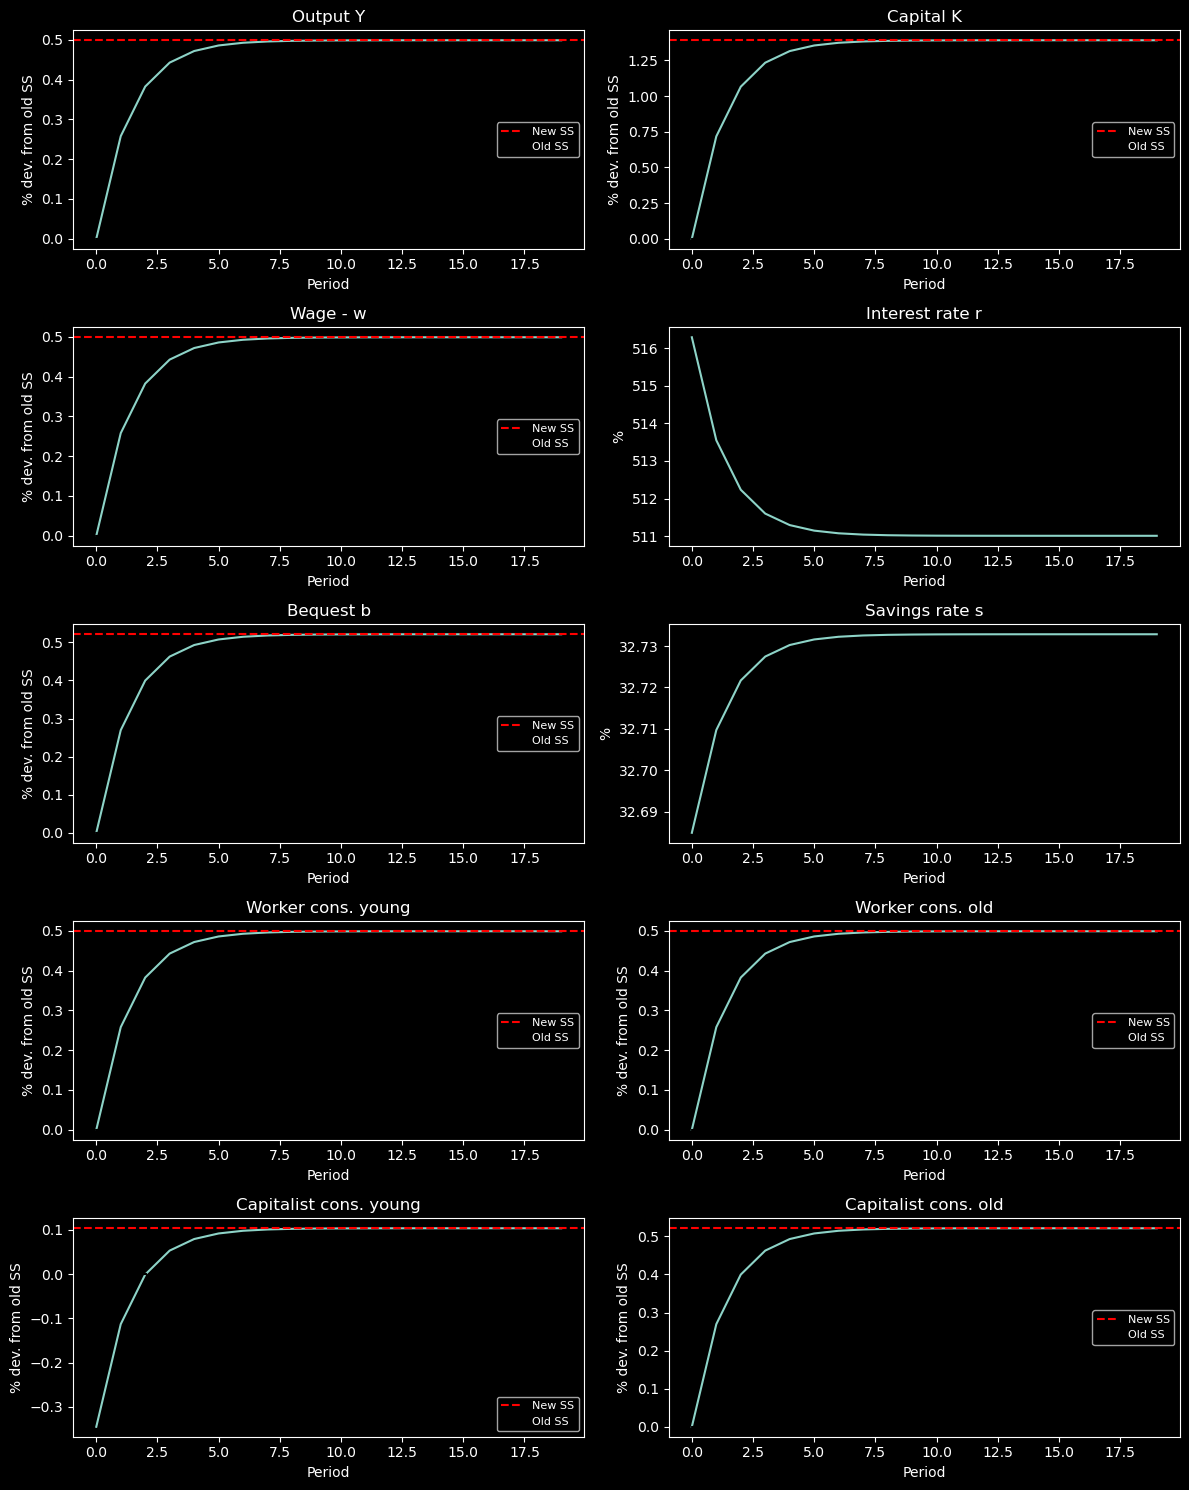

In [24]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))

pct_vars = [
    (sim6.Y, ss_no_tax.Y, ss_uncertain.Y, 'Output Y'),

    (sim6.K, ss_no_tax.K, ss_uncertain.K, 'Capital K'),
    (sim6.w, ss_no_tax.w, ss_uncertain.w, 'Wage - w'),
    (sim6.r, None, None, 'Interest rate r'),
    (sim6.b, ss_no_tax.b, ss_uncertain.b, 'Bequest b'),
    (sim6.s, None, None, 'Savings rate s'),
    (sim6.cw_y, ss_no_tax.cw_y, ss_uncertain.cw_y, 'Worker cons. young'),
    (sim6.cw_o, ss_no_tax.cw_o, ss_uncertain.cw_o, 'Worker cons. old'),
    (sim6.ck_y, ss_no_tax.ck_y, ss_uncertain.ck_y, 'Capitalist cons. young'),
    (sim6.ck_o, ss_no_tax.ck_o, ss_uncertain.ck_o, 'Capitalist cons. old'),
]

for i, (series, old, new, label) in enumerate(pct_vars):
    ax = axes[i // 2, i % 2]
    if old is None:
        ax.plot(100 * series)
        ax.set_ylabel('%')
    else:
        ax.plot(100 * (series - old) / old)
        ax.axhline(100 * (new - old) / old, color='red', linestyle='--', label='New SS')
        ax.axhline(0, color='black', linestyle='--', label='Old SS')
        ax.legend(fontsize=8)
        ax.set_ylabel('% dev. from old SS')
    ax.set_title(label)
    ax.set_xlabel('Period')

plt.tight_layout()
plt.show()



Comapred to part 2, the capital stock is higher due to to precautionary savings. Compared to part 5, the effect is smaller since the tax is never actually applied, The key is that uncertainty alone changes behaviour even without the tax being implemented. 